In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/flickr8k/captions.txt")

print(df.head())
print(df.shape)
len(df)

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  
(40455, 2)


40455

In [3]:
df.nunique()

image       8091
caption    40201
dtype: int64

In [4]:
counts = df.groupby("image").size()

print("Average captions per image:", counts.mean())
print("Min captions:", counts.min())
print("Max captions:", counts.max())

Average captions per image: 5.0
Min captions: 5
Max captions: 5


In [5]:
df["caption_length"] = df["caption"].apply(lambda x: len(x.split()))
df["caption_length"].describe()

count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64

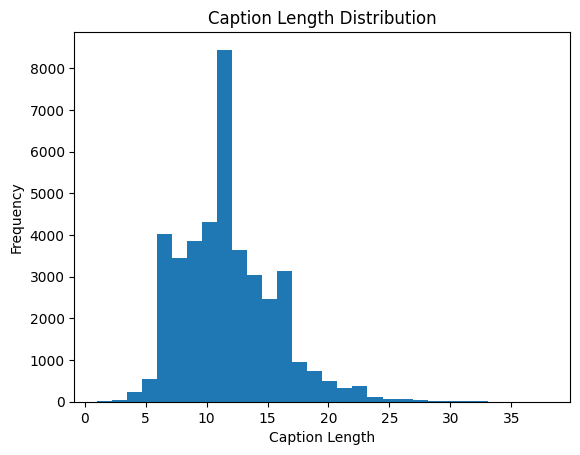

In [6]:
import matplotlib.pyplot as plt

plt.hist(df["caption_length"], bins=30)
plt.xlabel("Caption Length")
plt.ylabel("Frequency")
plt.title("Caption Length Distribution")
plt.show()

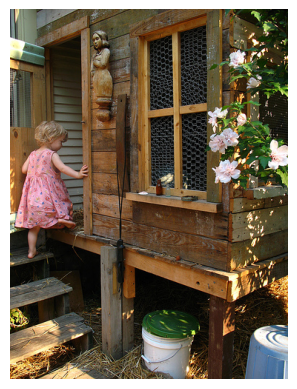

A child in a pink dress is climbing up a set of stairs in an entry way .
A girl going into a wooden building .
A little girl climbing into a wooden playhouse .
A little girl climbing the stairs to her playhouse .
A little girl in a pink dress going into a wooden cabin .


In [7]:
from PIL import Image
import matplotlib.pyplot as plt

image_name = df.iloc[0]["image"]

img = Image.open(f"../data/flickr8k/images/{image_name}")

plt.imshow(img)
plt.axis("off")
plt.show()

captions = df[df["image"] == image_name]["caption"]

for c in captions:
    print(c)


In [8]:
import itertools

all_words = list(
    itertools.chain.from_iterable(
        df["caption"].apply(lambda x: x.lower().split())
    )
)

vocab = set(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 8918


In [9]:
vocab = list(vocab)
vocab[:5]

['housing', 'rough', 'blown', 'seen', 'customer']

In [10]:
import string
import re

def clean_caption(caption):

    caption = caption.lower()

    caption = re.sub(r'[^a-z\s]', '', caption)

    caption = caption.strip()

    return caption

df["clean_caption"] = df["caption"].apply(clean_caption)
df["clean_caption"] = "<start> " + df["clean_caption"] + " <end>"
df[["caption","clean_caption"]].head(10)

,caption,clean_caption
0,A child in a pink dress is climbing up a set o...,<start> a child in a pink dress is climbing up...
1,A girl going into a wooden building .,<start> a girl going into a wooden building <end>
2,A little girl climbing into a wooden playhouse .,<start> a little girl climbing into a wooden p...
3,A little girl climbing the stairs to her playh...,<start> a little girl climbing the stairs to h...
4,A little girl in a pink dress going into a woo...,<start> a little girl in a pink dress going in...
5,A black dog and a spotted dog are fighting,<start> a black dog and a spotted dog are figh...
6,A black dog and a tri-colored dog playing with...,<start> a black dog and a tricolored dog playi...
7,A black dog and a white dog with brown spots a...,<start> a black dog and a white dog with brown...
8,Two dogs of different breeds looking at each o...,<start> two dogs of different breeds looking a...
9,Two dogs on pavement moving toward each other .,<start> two dogs on pavement moving toward eac...


In [11]:
all_words = " ".join(df["clean_caption"]).split()

vocab = set(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 8780


In [12]:
df["clean_caption"].apply(lambda x: len(x.split())).max()

np.int64(37)

In [13]:
from collections import Counter

all_words = []

for caption in df["clean_caption"]:
    all_words.extend(caption.split())

word_counts = Counter(all_words)

print("Total unique words:", len(word_counts))
word_counts

Total unique words: 8780


Counter({'a': 62986,
         '<start>': 40455,
         '<end>': 40455,
         'in': 18974,
         'the': 18418,
         'on': 10743,
         'is': 9345,
         'and': 8851,
         'dog': 8136,
         'with': 7765,
         'man': 7265,
         'of': 6713,
         'two': 5638,
         'white': 3940,
         'black': 3832,
         'boy': 3581,
         'are': 3504,
         'woman': 3402,
         'girl': 3328,
         'to': 3173,
         'wearing': 3062,
         'at': 2914,
         'people': 2883,
         'water': 2783,
         'red': 2672,
         'young': 2630,
         'brown': 2563,
         'an': 2432,
         'his': 2357,
         'blue': 2268,
         'dogs': 2125,
         'running': 2073,
         'through': 2032,
         'playing': 2008,
         'while': 1968,
         'down': 1825,
         'shirt': 1806,
         'standing': 1787,
         'ball': 1779,
         'little': 1768,
         'grass': 1622,
         'child': 1545,
         'person': 1

In [14]:
word2idx = {}
idx2word = {}

for idx, word in enumerate(word_counts.keys()):
    word2idx[word] = idx + 1
    idx2word[idx + 1] = word
word2idx

{'<start>': 1,
 'a': 2,
 'child': 3,
 'in': 4,
 'pink': 5,
 'dress': 6,
 'is': 7,
 'climbing': 8,
 'up': 9,
 'set': 10,
 'of': 11,
 'stairs': 12,
 'an': 13,
 'entry': 14,
 'way': 15,
 '<end>': 16,
 'girl': 17,
 'going': 18,
 'into': 19,
 'wooden': 20,
 'building': 21,
 'little': 22,
 'playhouse': 23,
 'the': 24,
 'to': 25,
 'her': 26,
 'cabin': 27,
 'black': 28,
 'dog': 29,
 'and': 30,
 'spotted': 31,
 'are': 32,
 'fighting': 33,
 'tricolored': 34,
 'playing': 35,
 'with': 36,
 'each': 37,
 'other': 38,
 'on': 39,
 'road': 40,
 'white': 41,
 'brown': 42,
 'spots': 43,
 'staring': 44,
 'at': 45,
 'street': 46,
 'two': 47,
 'dogs': 48,
 'different': 49,
 'breeds': 50,
 'looking': 51,
 'pavement': 52,
 'moving': 53,
 'toward': 54,
 'covered': 55,
 'paint': 56,
 'sits': 57,
 'front': 58,
 'painted': 59,
 'rainbow': 60,
 'hands': 61,
 'bowl': 62,
 'sitting': 63,
 'large': 64,
 'small': 65,
 'grass': 66,
 'plays': 67,
 'fingerpaints': 68,
 'canvas': 69,
 'it': 70,
 'there': 71,
 'pigtails': 

In [15]:
print(word2idx["dog"])
print(idx2word[10])

29
set


In [16]:
def caption_to_sequence(caption):

    return [word2idx[word] for word in caption.split()]
df["sequence"] = df["clean_caption"].apply(caption_to_sequence)
df.head(5)

,image,caption,caption_length,clean_caption,sequence
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,18,<start> a child in a pink dress is climbing up...,"[1, 2, 3, 4, 2, 5, 6, 7, 8, 9, 2, 10, 11, 12, ..."
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,8,<start> a girl going into a wooden building <end>,"[1, 2, 17, 18, 19, 2, 20, 21, 16]"
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,9,<start> a little girl climbing into a wooden p...,"[1, 2, 22, 17, 8, 19, 2, 20, 23, 16]"
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,10,<start> a little girl climbing the stairs to h...,"[1, 2, 22, 17, 8, 24, 12, 25, 26, 23, 16]"
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,13,<start> a little girl in a pink dress going in...,"[1, 2, 22, 17, 4, 2, 5, 6, 18, 19, 2, 20, 27, 16]"


In [17]:
df["sequence"].shape

(40455,)

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LENGTH = 40

df["padded_sequence"] = pad_sequences(
    df["sequence"],
    maxlen=MAX_LENGTH,
    padding="post"
).tolist()
df["padded_sequence"].head()

0    [1, 2, 3, 4, 2, 5, 6, 7, 8, 9, 2, 10, 11, 12, ...
1    [1, 2, 17, 18, 19, 2, 20, 21, 16, 0, 0, 0, 0, ...
2    [1, 2, 22, 17, 8, 19, 2, 20, 23, 16, 0, 0, 0, ...
3    [1, 2, 22, 17, 8, 24, 12, 25, 26, 23, 16, 0, 0...
4    [1, 2, 22, 17, 4, 2, 5, 6, 18, 19, 2, 20, 27, ...
Name: padded_sequence, dtype: object

In [19]:
len(df["padded_sequence"][0])

40

<Axes: >

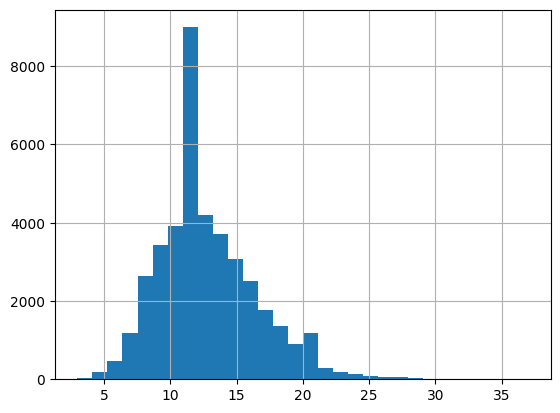

In [20]:
df["clean_caption"].apply(lambda x: len(x.split())).hist(bins=30)

In [21]:
df.head()

,image,caption,caption_length,clean_caption,sequence,padded_sequence
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,18,<start> a child in a pink dress is climbing up...,"[1, 2, 3, 4, 2, 5, 6, 7, 8, 9, 2, 10, 11, 12, ...","[1, 2, 3, 4, 2, 5, 6, 7, 8, 9, 2, 10, 11, 12, ..."
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,8,<start> a girl going into a wooden building <end>,"[1, 2, 17, 18, 19, 2, 20, 21, 16]","[1, 2, 17, 18, 19, 2, 20, 21, 16, 0, 0, 0, 0, ..."
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,9,<start> a little girl climbing into a wooden p...,"[1, 2, 22, 17, 8, 19, 2, 20, 23, 16]","[1, 2, 22, 17, 8, 19, 2, 20, 23, 16, 0, 0, 0, ..."
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,10,<start> a little girl climbing the stairs to h...,"[1, 2, 22, 17, 8, 24, 12, 25, 26, 23, 16]","[1, 2, 22, 17, 8, 24, 12, 25, 26, 23, 16, 0, 0..."
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,13,<start> a little girl in a pink dress going in...,"[1, 2, 22, 17, 4, 2, 5, 6, 18, 19, 2, 20, 27, 16]","[1, 2, 22, 17, 4, 2, 5, 6, 18, 19, 2, 20, 27, ..."


In [22]:
df.iloc[2]

image                                      1000268201_693b08cb0e.jpg
caption             A little girl climbing into a wooden playhouse .
caption_length                                                     9
clean_caption      <start> a little girl climbing into a wooden p...
sequence                        [1, 2, 22, 17, 8, 19, 2, 20, 23, 16]
padded_sequence    [1, 2, 22, 17, 8, 19, 2, 20, 23, 16, 0, 0, 0, ...
Name: 2, dtype: object

In [25]:
df["clean_caption"]

0        <start> a child in a pink dress is climbing up...
1        <start> a girl going into a wooden building <end>
2        <start> a little girl climbing into a wooden p...
3        <start> a little girl climbing the stairs to h...
4        <start> a little girl in a pink dress going in...
                               ...                        
40450    <start> a man in a pink shirt climbs a rock fa...
40451    <start> a man is rock climbing high in the air...
40452    <start> a person in a red shirt climbing up a ...
40453          <start> a rock climber in a red shirt <end>
40454    <start> a rock climber practices on a rock cli...
Name: clean_caption, Length: 40455, dtype: object

In [28]:
df["caption"].head()

0    A child in a pink dress is climbing up a set o...
1                A girl going into a wooden building .
2     A little girl climbing into a wooden playhouse .
3    A little girl climbing the stairs to her playh...
4    A little girl in a pink dress going into a woo...
Name: caption, dtype: object